## 1. Librerías

In [349]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Planteo de hipótesis

    # H1: a mayor antelación, mayor probabilidad de que la reserva no se complete.
    # H2: a más ancillaries solicitados (extra baggage, seat, meals), menor probabilidad de que la reserva no se complete.
    # H3: la conversión depende del país desde donde se reserva.
    # H4: Ante exactamente la misma ruta es mas barato Mobile que Web.

## 3. Carga, análisis y limpieza de datos


# Carga

In [350]:

df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.shape

(50000, 15)

# 4. Análisis

In [351]:

df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,987.30
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,406.91
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,875.51
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,508.69
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,1097.63


In [352]:
df.tail()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0,1383.71
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0,476.71
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0,587.70
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0,653.75
49999,1,Internet,RoundTrip,19,6,10,Thu,PERPNH,Australia,0,1,0,5.62,0,692.88


In [353]:
df.sample(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
15190,1,Internet,RoundTrip,120,85,10,Sat,JHBKIX,Japan,1,1,1,7.00,0,941.98
3082,1,Internet,RoundTrip,19,25,7,Fri,BWNKTM,Brunei,1,0,0,4.75,1,650.79
23946,1,Internet,RoundTrip,133,18,8,Wed,PERTRZ,Australia,1,0,0,5.62,0,415.82
30895,2,Internet,RoundTrip,341,4,20,Sun,DMKMEL,Thailand,0,0,0,8.83,0,1583.88
29435,1,Internet,RoundTrip,9,4,8,Wed,BDOPER,Australia,0,0,0,5.62,0,676.70
12521,1,Internet,RoundTrip,41,34,12,Sun,HNDPEN,Japan,0,1,0,7.57,0,726.42
44194,1,Internet,RoundTrip,22,6,3,Tue,CTUMEL,China,1,0,0,8.83,0,993.12
35756,1,Internet,RoundTrip,36,5,11,Mon,CGKKIX,Japan,1,0,0,7.00,0,791.43
38624,1,Internet,RoundTrip,258,5,13,Tue,HKTTPE,Taiwan,0,1,1,4.67,0,294.79
20470,3,Internet,RoundTrip,40,78,13,Tue,MELTPE,Taiwan,1,0,0,8.83,0,2031.15


In [354]:
df.info()

## No hay nulos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  booking_cost           50000 non-null  float64
dtypes:

In [355]:
df.sales_channel.unique()


array(['Internet', 'Mobile'], dtype=object)

In [356]:
df.trip_type.unique()

array(['RoundTrip', 'CircleTrip', 'OneWay'], dtype=object)

In [357]:
df.flight_day.unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [358]:
df.booking_origin.unique()

array(['New Zealand', 'India', 'United Kingdom', 'China', 'South Korea',
       'Japan', 'Malaysia', 'Singapore', 'Switzerland', 'Germany',
       'Indonesia', 'Czech Republic', 'Vietnam', 'Thailand', 'Spain',
       'Romania', 'Ireland', 'Italy', 'Slovakia', 'United Arab Emirates',
       'Tonga', 'Rï¿½union', '(not set)', 'Saudi Arabia', 'Netherlands',
       'Qatar', 'Hong Kong', 'Philippines', 'Sri Lanka', 'France',
       'Croatia', 'United States', 'Laos', 'Hungary', 'Portugal',
       'Cyprus', 'Australia', 'Cambodia', 'Poland', 'Belgium', 'Oman',
       'Bangladesh', 'Kazakhstan', 'Brazil', 'Turkey', 'Kenya', 'Taiwan',
       'Brunei', 'Chile', 'Bulgaria', 'Ukraine', 'Denmark', 'Colombia',
       'Iran', 'Bahrain', 'Solomon Islands', 'Slovenia', 'Mauritius',
       'Nepal', 'Russia', 'Kuwait', 'Mexico', 'Sweden', 'Austria',
       'Lebanon', 'Jordan', 'Greece', 'Mongolia', 'Canada', 'Tanzania',
       'Peru', 'Timor-Leste', 'Argentina', 'New Caledonia', 'Macau',
       'Myanmar

In [359]:
df.booking_complete.unique()

## 0 No finalizado / 1 finalizado

array([0, 1])

In [360]:
df.describe()

# Valores atipicos:
# num_passengers (9 con promedio 1.59), 
# purchase_lead (867 con promedio de 84), 
# length_of_stay (778 con promedio 23.044)
# flight_hour (23 con promedio de 9.06) -> aunque no veo que sea relevante en las hipótesis.
# wants_extra_baggage, wants_preferred_seat, wants_in_flight_meals y booking_complete son binarios.
# booking_cost (7545.36 con promedio de 1097.63)

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,booking_cost
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560,1097.632107
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643,673.572374
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000,215.100000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000,667.150000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000,883.150000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000,1323.627500
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000,7545.360000


# Limpieza

In [361]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje (%)': (nulos / len(df) * 100).round(2)})
nulos_df

# No hay nulos

,nulos,porcentaje (%)


In [362]:
# Duplicados

In [363]:
duplicados = df.duplicated().sum()
print(f'Duplicados exactos: {duplicados:,}  ({duplicados / len(df) * 100:.2f} %)')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas tras eliminar duplicados: {len(df):,}')

Duplicados exactos: 420  (0.84 %)
Filas tras eliminar duplicados: 49,580


In [364]:
# Inconsistencias

In [365]:
# Se eliminan las reservas que no corresponden: las que incumplen alguna de las reglas de arriba.
# Los valores extremos pero posibles (p. ej. compras con mucha anticipación) se conservan y se analizan como outliers.
origen, destino = df["route"].str[:3], df["route"].str[3:]
columnas_binarias = ["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals", "booking_complete"]

reglas_invalidas = {
    "Sin pasajeros": df["num_passengers"] <= 0,
    "booking_cost cero o negativo": df["booking_cost"] <= 0,
    "Anticipación de compra negativa": df["purchase_lead"] < 0,
    "Estadía negativa": df["length_of_stay"] < 0,
    "Hora de vuelo fuera de 0-23": ~df["flight_hour"].between(0, 23),
    "Duración de vuelo <= 0": df["flight_duration"] <= 0,
    "Día de vuelo inválido": ~df["flight_day"].isin(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]),
    "Canal de venta inválido": ~df["sales_channel"].isin(["Internet", "Mobile"]),
    "Tipo de viaje inválido": ~df["trip_type"].isin(["RoundTrip", "OneWay", "CircleTrip"]),
    "Binarias distintas de 0 y 1": (~df[columnas_binarias].isin([0, 1])).any(axis=1),
    "Ruta con formato inválido": ~df["route"].str.fullmatch(r"[A-Z]{6}"),
    "Ruta con origen igual a destino": origen == destino,
    "booking_origin vacío": df["booking_origin"].str.strip().eq(""),
    "Solo ida con días de estadía": (df["trip_type"] == "OneWay") & (df["length_of_stay"] > 0),
}

# Filas eliminadas por cada regla (una fila puede incumplir más de una)
print(pd.Series({regla: mascara.sum() for regla, mascara in reglas_invalidas.items()}, name="filas").to_string())

filas_antes = len(df)
invalidas = pd.concat(reglas_invalidas.values(), axis=1).any(axis=1)
df = df[~invalidas].reset_index(drop=True)
print(f"\nFilas eliminadas: {filas_antes - len(df):,} | Filas finales: {len(df):,}")

Sin pasajeros                        0
booking_cost cero o negativo         0
Anticipación de compra negativa      0
Estadía negativa                     0
Hora de vuelo fuera de 0-23          0
Duración de vuelo <= 0               0
Día de vuelo inválido                0
Canal de venta inválido              0
Tipo de viaje inválido               0
Binarias distintas de 0 y 1          0
Ruta con formato inválido            0
Ruta con origen igual a destino      0
booking_origin vacío                 0
Solo ida con días de estadía       378

Filas eliminadas: 378 | Filas finales: 49,202


## EDA

Data columns (total 15 columns):
Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  booking_cost           50000 non-null  float64

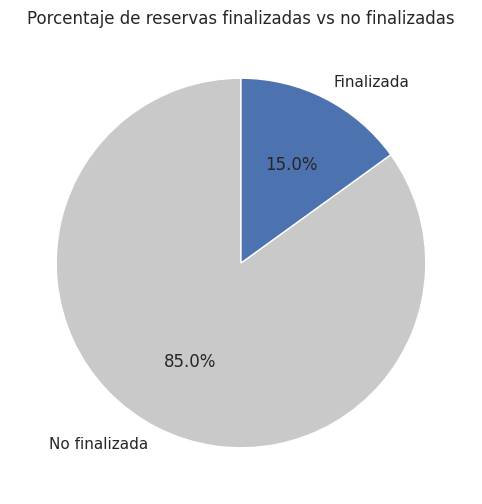

In [366]:
# Porcentaje de finalizadas

plt.figure(figsize=(8,6))
conteo_status = df['booking_complete'].value_counts().sort_index()
plt.pie(conteo_status, labels=['No finalizada', 'Finalizada'], autopct='%1.1f%%', startangle=90,
        colors=['#c9c9c9', '#4c72b0'])
plt.title("Porcentaje de reservas finalizadas vs no finalizadas")
plt.show()

### Construcción de columnas auxiliares

- `origin` y `destination`: aeropuertos de origen y destino, extraídos de `route`.
- `flight_day` (ordenado) y `flight_day_num`: día de la semana de lunes a domingo, para graficar en orden.
- `is_weekend_flight`: 1 si el vuelo es sábado o domingo.
- `flight_period`: momento del día del vuelo (madrugada, mañana, tarde o noche).
- `lead_group`: grupo de anticipación de la compra, por mes (30 días) durante 12 meses (Mes 1 = 0-30 días, Mes 2 = 31-60, etc.) más un grupo para más de 12 meses.
- `total_extras`: cantidad de adicionales pedidos (equipaje, asiento preferido y comidas), de 0 a 3.
- `has_extras`: 1 si la reserva pidió al menos un adicional (equipaje, asiento preferido o comidas), 0 si no pidió ninguno.
- `cost_per_passenger`: costo de la reserva dividido por la cantidad de pasajeros.
- `group_type`: tipo de reserva según la cantidad de pasajeros (solo, pareja o grupo).

In [367]:
# Origen y destino: las 3 primeras y las 3 últimas letras de la ruta
df["origin"] = df["route"].str[:3]
df["destination"] = df["route"].str[3:]

# Día de vuelo como categoría ordenada de lunes a domingo, con su número (1 = lunes)
dias_orden = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["flight_day"] = pd.Categorical(df["flight_day"], categories=dias_orden, ordered=True)
df["flight_day_num"] = df["flight_day"].cat.codes + 1
df["is_weekend_flight"] = df["flight_day"].isin(["Sat", "Sun"]).astype(int)

# Momento del día según la hora del vuelo
df["flight_period"] = pd.cut(
    df["flight_hour"], bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada (0-5)", "Mañana (6-11)", "Tarde (12-17)", "Noche (18-23)"],
)

# Grupos de anticipación de la compra (en días)
df["lead_group"] = pd.cut(
    df["purchase_lead"], bins=list(range(-1, 361, 30)) + [df["purchase_lead"].max()],
    labels=[f"Mes {m}" for m in range(1, 13)] + ["Más de 12 meses"],
)

# Adicionales pedidos por reserva (0 a 3) y costo por pasajero
df["total_extras"] = df[["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals"]].sum(axis=1)
df["has_extras"] = (df["total_extras"] > 0).astype(int)
df["cost_per_passenger"] = (df["booking_cost"] / df["num_passengers"]).round(2)

# Tipo de reserva según la cantidad de pasajeros
df["group_type"] = pd.cut(
    df["num_passengers"], bins=[0, 1, 2, df["num_passengers"].max()],
    labels=["Solo (1)", "Pareja (2)", "Grupo (3 o más)"],
)

df[["origin", "destination", "flight_day", "flight_day_num", "is_weekend_flight", "flight_period",
    "lead_group", "total_extras", "has_extras", "cost_per_passenger", "group_type"]].head()

,origin,destination,flight_day,flight_day_num,is_weekend_flight,flight_period,lead_group,total_extras,has_extras,cost_per_passenger,group_type
0,AKL,DEL,Sat,6,1,Mañana (6-11),Mes 9,1,1,493.65,Pareja (2)
1,AKL,DEL,Sat,6,1,Madrugada (0-5),Mes 4,0,0,406.91,Solo (1)
2,AKL,DEL,Wed,3,0,Tarde (12-17),Mes 9,2,1,437.76,Pareja (2)
3,AKL,DEL,Sat,6,1,Madrugada (0-5),Mes 4,1,1,508.69,Solo (1)
4,AKL,DEL,Wed,3,0,Tarde (12-17),Mes 3,2,1,548.82,Pareja (2)


In [368]:
# Cantidad de reservas en cada grupo, para verificar que ninguno quede vacío
for columna in ["flight_period", "lead_group", "group_type", "total_extras", "has_extras"]:
    print(df[columna].value_counts().sort_index().to_string(), "\n")

flight_period
Madrugada (0-5)    14379
Mañana (6-11)      18383
Tarde (12-17)      13506
Noche (18-23)       2934 

lead_group
Mes 1              16525
Mes 2              10638
Mes 3               6347
Mes 4               3942
Mes 5               2551
Mes 6               2059
Mes 7               1576
Mes 8               1431
Mes 9               1193
Mes 10               841
Mes 11               612
Mes 12               586
Más de 12 meses      901 

group_type
Solo (1)           30822
Pareja (2)         12640
Grupo (3 o más)     5740 

total_extras
0    10318
1    17905
2    12343
3     8636 

has_extras
0    10318
1    38884 



## Análisis exploratorio

En todo el análisis, **conversión** es el porcentaje de reservas completadas (`booking_complete = 1`) y "reserva no completada" es una reserva que el cliente no finalizó. El dataset no informa el motivo.

Para las hipótesis de rutas (H3) y países (H4) se arman dos tablas auxiliares con la cantidad de reservas y la conversión de cada ruta y de cada país.

In [369]:
# Tabla por ruta: cantidad de reservas y conversión (%)
por_ruta = (df.groupby('route')['booking_complete']
              .agg(reservas='size', conversion='mean').reset_index()
              .sort_values('reservas', ascending=False).reset_index(drop=True))
por_ruta['conversion'] = por_ruta['conversion'] * 100

# Tabla por país de origen de la reserva: cantidad de reservas y conversión (%)
por_pais = (df.groupby('booking_origin')['booking_complete']
              .agg(reservas='size', conversion='mean').reset_index()
              .sort_values('reservas', ascending=False).reset_index(drop=True))
por_pais['conversion'] = por_pais['conversion'] * 100

print(f"Rutas distintas: {len(por_ruta)}  |  Países de origen distintos: {len(por_pais)}")
por_ruta.head()

Rutas distintas: 798  |  Países de origen distintos: 103


,route,reservas,conversion
0,AKLKUL,2620,21.488550
1,PENTPE,917,43.402399
2,MELSGN,841,5.112961
3,ICNSIN,793,11.223203
4,DMKKIX,736,25.135870


## Histogramas con KDE


- **H1:** anticipación de la compra, completadas vs no completadas (hasta el percentil 99).
- **H3:** duración de la estadía en Australia (5 % de conversión) vs Malasia (34,5 %),
  los dos mercados más grandes con conversiones opuestas. Sirve para buscar una posible explicación de la diferencia.
- **H4:** precio por pasajero relativo a la mediana de su ruta, Internet vs Mobile.
  Si Mobile fuera más barato, su curva estaría corrida a la izquierda del 1.

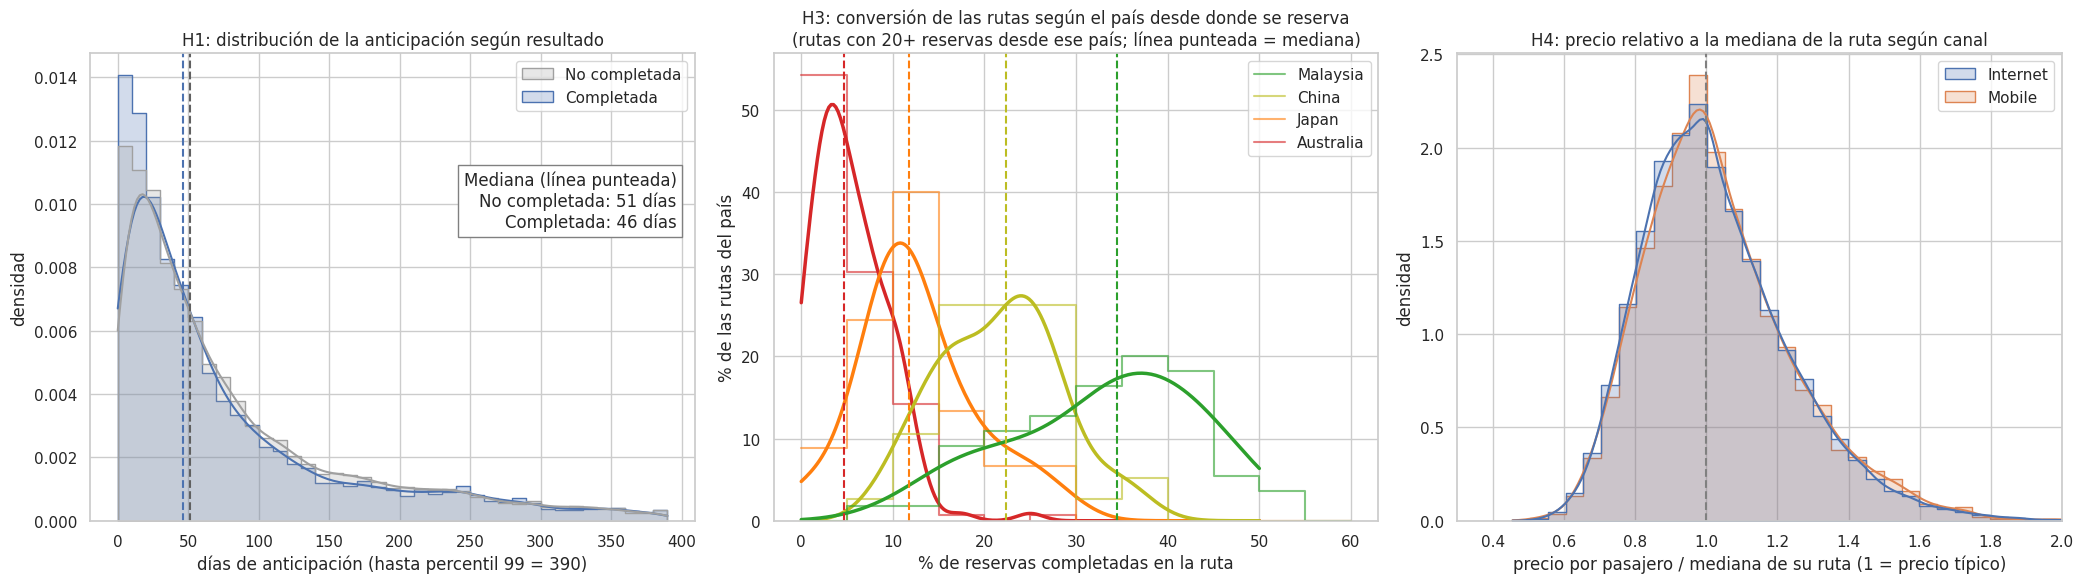

In [370]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# H1: anticipación de la compra, completadas vs no completadas
p99_lead = df['purchase_lead'].quantile(0.99)
datos_h1 = df[df['purchase_lead'] <= p99_lead].copy()
datos_h1['resultado'] = datos_h1['booking_complete'].map({0: 'No completada', 1: 'Completada'})
sns.histplot(data=datos_h1, x='purchase_lead', hue='resultado', hue_order=['No completada', 'Completada'],
             stat='density', common_norm=False, kde=True, binwidth=10, element='step',
             palette=['#a0a0a0', '#4c72b0'], ax=axes[0])
medianas_h1 = datos_h1.groupby('resultado')['purchase_lead'].median()
for nombre, color in [('No completada', '#606060'), ('Completada', '#4c72b0')]:
    axes[0].axvline(medianas_h1[nombre], color=color, linestyle='--')
axes[0].text(0.97, 0.75, f"Mediana (línea punteada)\nNo completada: {medianas_h1['No completada']:.0f} días\n"
             f"Completada: {medianas_h1['Completada']:.0f} días", transform=axes[0].transAxes,
             ha='right', va='top', bbox={'facecolor': 'white', 'edgecolor': 'gray'})
axes[0].set_title('H1: distribución de la anticipación según resultado')
axes[0].set_xlabel(f'días de anticipación (hasta percentil 99 = {p99_lead:.0f})')
axes[0].set_ylabel('densidad')
axes[0].get_legend().set_title('')

# H3: conversión de cada ruta, separando según el país desde donde se reservó
# Cada dato es una combinación país-ruta con 20+ reservas (con menos, el % es poco confiable)
paises_h3 = ['Malaysia', 'China', 'Japan', 'Australia']
colores_h3 = ['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']
conv_ruta_pais = (df[df['booking_origin'].isin(paises_h3)]
                    .groupby(['booking_origin', 'route'])['booking_complete']
                    .agg(reservas='size', conversion='mean').reset_index())
conv_ruta_pais = conv_ruta_pais[conv_ruta_pais['reservas'] >= 20]
conv_ruta_pais['conversion'] *= 100

sns.histplot(data=conv_ruta_pais, x='conversion', hue='booking_origin', hue_order=paises_h3,
             stat='percent', common_norm=False, binwidth=5, binrange=(0, 60), kde=True,
             kde_kws={'clip': (0, 100)}, element='step', fill=False, alpha=0.6,
             line_kws={'linewidth': 2.5}, palette=colores_h3, ax=axes[1])
# Mediana de cada país como línea punteada
for pais, color in zip(paises_h3, colores_h3):
    mediana = conv_ruta_pais.loc[conv_ruta_pais['booking_origin'] == pais, 'conversion'].median()
    axes[1].axvline(mediana, color=color, linestyle='--')
axes[1].set_title('H3: conversión de las rutas según el país desde donde se reserva\n'
                  '(rutas con 20+ reservas desde ese país; línea punteada = mediana)')
axes[1].set_xlabel('% de reservas completadas en la ruta')
axes[1].set_ylabel('% de las rutas del país')
axes[1].get_legend().set_title('')

# H4: precio por pasajero relativo a la mediana de su ruta, por canal (solo rutas con ambos canales)
canales_por_ruta = df.groupby('route')['sales_channel'].nunique()
datos_h4 = df[df['route'].isin(canales_por_ruta[canales_por_ruta == 2].index)].copy()
datos_h4['precio_relativo'] = (datos_h4['cost_per_passenger'] /
                               datos_h4.groupby('route')['cost_per_passenger'].transform('median'))
sns.histplot(data=datos_h4, x='precio_relativo', hue='sales_channel', hue_order=['Internet', 'Mobile'],
             stat='density', common_norm=False, kde=True, binwidth=0.05, element='step',
             palette=['#4c72b0', '#dd8452'], ax=axes[2])
axes[2].axvline(1, color='gray', linestyle='--')
axes[2].set_xlim(0.3, 2.0)
axes[2].set_title('H4: precio relativo a la mediana de la ruta según canal')
axes[2].set_xlabel('precio por pasajero / mediana de su ruta (1 = precio típico)')
axes[2].set_ylabel('densidad')
axes[2].get_legend().set_title('')

plt.tight_layout()
plt.show()

### Boxplots — detección de outliers

- **H1:** `purchase_lead` según reserva completada (0 = no, 1 = sí).
- **H2:** `purchase_lead` según cantidad de extras solicitados.
- **H3:** cantidad de reservas por ruta. Los puntos por encima de la caja son las rutas con mucha más demanda que el resto, es decir, las rutas populares.

En H1 y H2 el eje se limita al percentil 99; los valores por encima siguen en el dataset.

In [371]:
# Cuantifica los outliers de cada variable con el criterio IQR (el mismo que usa el boxplot)
def resumen_outliers(df, columnas):
    filas = []
    for col in columnas:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        filas.append({'variable': col, 'Q1': q1, 'mediana': df[col].median(), 'Q3': q3,
                      'límite superior': lim_sup, 'máximo': df[col].max(),
                      'outliers': n_out, '% outliers': round(n_out / len(df) * 100, 1)})
    return pd.DataFrame(filas).set_index('variable').round(1)

resumen_outliers(df, ['purchase_lead', 'num_passengers', 'booking_cost', 'cost_per_passenger'])

,Q1,mediana,Q3,límite superior,máximo,outliers,% outliers
variable,,,,,,,
purchase_lead,21.0,51.0,115.0,256.0,867.0,3381,6.9
num_passengers,1.0,1.0,2.0,3.5,9.0,2849,5.8
booking_cost,669.6,885.8,1328.3,2316.4,7545.4,2887,5.9
cost_per_passenger,562.8,698.9,844.9,1268.1,2164.1,707,1.4


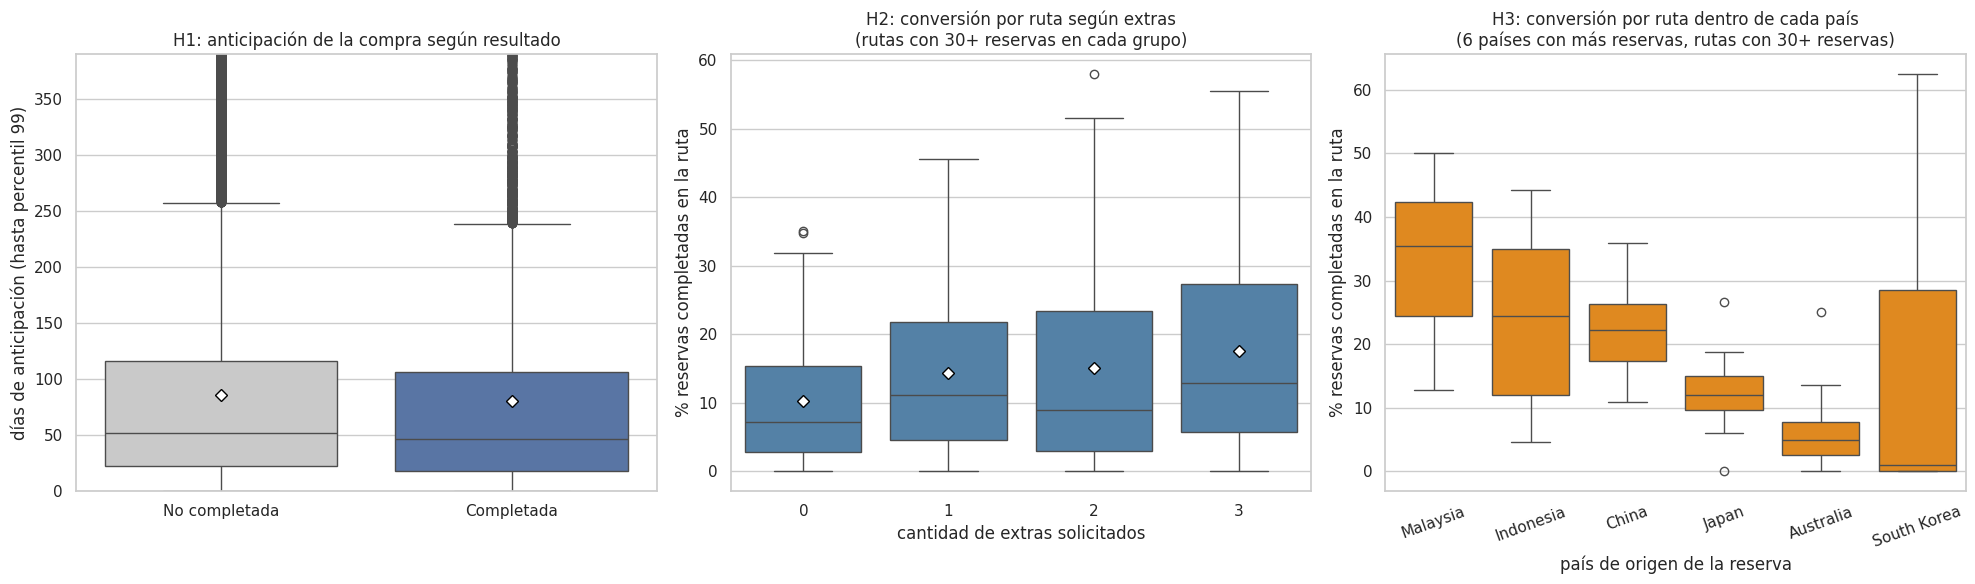

In [372]:
MIN_RESERVAS = 30  # mínimo de reservas para que la conversión de una ruta sea confiable

# H2: conversión de cada ruta según la cantidad de extras
conv_ruta_extras = (df.groupby(['route', 'total_extras'])['booking_complete']
                      .agg(reservas='size', conversion='mean').reset_index())
conv_ruta_extras = conv_ruta_extras[conv_ruta_extras['reservas'] >= MIN_RESERVAS]
conv_ruta_extras['conversion'] *= 100

# H3: conversión de cada ruta dentro de los 6 países con más reservas
top6_paises = df['booking_origin'].value_counts().head(6).index
conv_pais_ruta = (df[df['booking_origin'].isin(top6_paises)]
                    .groupby(['booking_origin', 'route'])['booking_complete']
                    .agg(reservas='size', conversion='mean').reset_index())
conv_pais_ruta = conv_pais_ruta[conv_pais_ruta['reservas'] >= MIN_RESERVAS]
conv_pais_ruta['conversion'] *= 100
orden_paises = conv_pais_ruta.groupby('booking_origin')['conversion'].median().sort_values(ascending=False).index

estilo_media = {'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black'}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# H1: anticipación de las reservas completadas vs no completadas
sns.boxplot(data=df, x='booking_complete', y='purchase_lead', hue='booking_complete',
            palette=['#c9c9c9', '#4c72b0'], legend=False, showmeans=True, meanprops=estilo_media, ax=axes[0])
axes[0].set_ylim(0, df['purchase_lead'].quantile(0.99))
axes[0].set_xticks([0, 1], ['No completada', 'Completada'])
axes[0].set_title('H1: anticipación de la compra según resultado')
axes[0].set_xlabel('')
axes[0].set_ylabel('días de anticipación (hasta percentil 99)')

# H2: cada caja es la distribución de la conversión de las rutas, para 0, 1, 2 y 3 extras
sns.boxplot(data=conv_ruta_extras, x='total_extras', y='conversion', color='steelblue',
            showmeans=True, meanprops=estilo_media, ax=axes[1])
axes[1].set_title(f'H2: conversión por ruta según extras\n(rutas con {MIN_RESERVAS}+ reservas en cada grupo)')
axes[1].set_xlabel('cantidad de extras solicitados')
axes[1].set_ylabel('% reservas completadas en la ruta')

# H3: cada caja es la conversión de las rutas reservadas desde ese país
sns.boxplot(data=conv_pais_ruta, x='booking_origin', y='conversion', order=orden_paises,
            color='darkorange', ax=axes[2])
axes[2].set_title(f'H3: conversión por ruta dentro de cada país\n(6 países con más reservas, rutas con {MIN_RESERVAS}+ reservas)')
axes[2].set_xlabel('país de origen de la reserva')
axes[2].set_ylabel('% reservas completadas en la ruta')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Scatterplots

- **H3:** cada punto es un **país** (con 100+ reservas). Eje x: cantidad de reservas (escala log);
  eje y: conversión. El tamaño del punto es la cantidad de reservas y el color va de rojo (baja conversión)
  a verde (alta). La línea punteada es la conversión global. Si la conversión no dependiera del país,
  todos los puntos estarían cerca de esa línea.
- **H4:** cada punto es una **ruta** vendida por ambos canales (10+ reservas en cada uno).
  Eje x: precio mediano por pasajero en Internet; eje y: el mismo precio en Mobile.
  La diagonal es "mismo precio": **debajo de la diagonal Mobile es más barato** y arriba, más caro.
  Se usa el costo **por pasajero** para que no influya el tamaño del grupo.

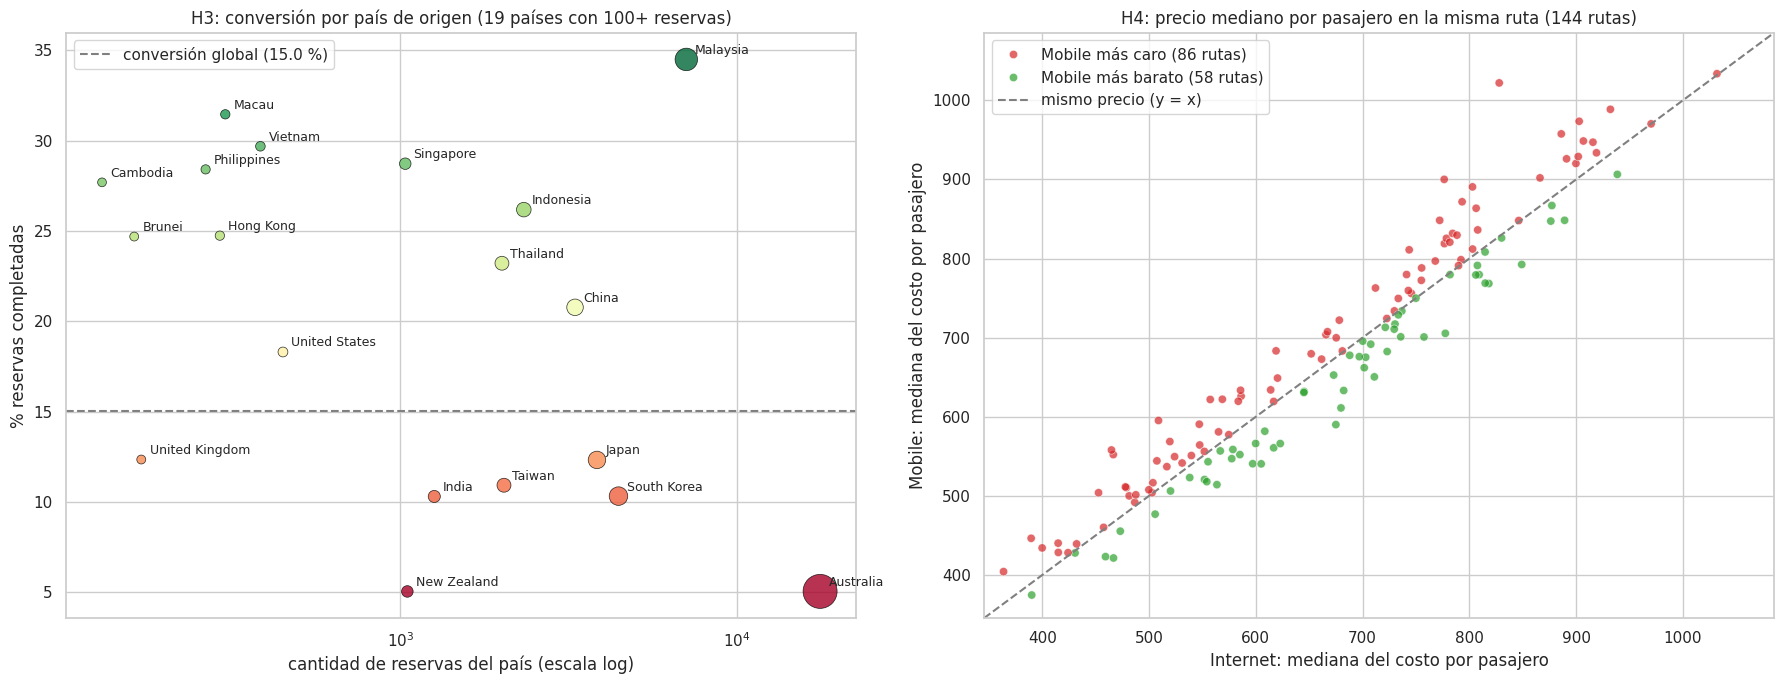

Correlación reservas vs conversión (países): -0.36
Correlación precio Internet vs Mobile (rutas): 0.96


In [373]:
conversion_global = df['booking_complete'].mean() * 100

# H3: una fila por país con su cantidad de reservas y su conversión (%)
por_pais = (df.groupby('booking_origin')['booking_complete']
              .agg(reservas='size', conversion='mean').reset_index())
por_pais['conversion'] *= 100
paises_100 = por_pais[por_pais['reservas'] >= 100]  # con pocas reservas la conversión es inestable

# H4: mediana del costo por pasajero de cada canal en cada ruta (10+ reservas por canal)
mediana_canal = (df.groupby(['route', 'sales_channel'])['cost_per_passenger']
                   .agg(['size', 'median']).reset_index())
mediana_canal = (mediana_canal[mediana_canal['size'] >= 10]
                   .pivot(index='route', columns='sales_channel', values='median').dropna())
mas_barato = mediana_canal['Mobile'] < mediana_canal['Internet']
mediana_canal['comparacion'] = np.where(mas_barato, f'Mobile más barato ({mas_barato.sum()} rutas)',
                                        f'Mobile más caro ({(~mas_barato).sum()} rutas)')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# H3: cada punto es un país; el tamaño indica la cantidad de reservas
sns.scatterplot(data=paises_100, x='reservas', y='conversion', size='reservas', sizes=(40, 600),
                hue='conversion', palette='RdYlGn', edgecolor='black', alpha=0.8, legend=False, ax=axes[0])
axes[0].set_xscale('log')
axes[0].axhline(conversion_global, color='gray', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
for _, fila in paises_100.iterrows():
    axes[0].annotate(fila['booking_origin'], (fila['reservas'], fila['conversion']),
                     xytext=(6, 4), textcoords='offset points', fontsize=9)
axes[0].set_title(f'H3: conversión por país de origen ({len(paises_100)} países con 100+ reservas)')
axes[0].set_xlabel('cantidad de reservas del país (escala log)')
axes[0].set_ylabel('% reservas completadas')
axes[0].legend(loc='upper left')

# H4: cada punto es una ruta; debajo de la diagonal, Mobile es más barato que Internet
sns.scatterplot(data=mediana_canal, x='Internet', y='Mobile', hue='comparacion',
                palette=['#d62728', '#2ca02c'], hue_order=sorted(mediana_canal['comparacion'].unique(), reverse=True),
                alpha=0.7, ax=axes[1])
limites = [mediana_canal[['Internet', 'Mobile']].min().min() * 0.95,
           mediana_canal[['Internet', 'Mobile']].max().max() * 1.05]
axes[1].plot(limites, limites, color='gray', linestyle='--', label='mismo precio (y = x)')
axes[1].set_xlim(limites)
axes[1].set_ylim(limites)
axes[1].set_title(f'H4: precio mediano por pasajero en la misma ruta ({len(mediana_canal)} rutas)')
axes[1].set_xlabel('Internet: mediana del costo por pasajero')
axes[1].set_ylabel('Mobile: mediana del costo por pasajero')
axes[1].legend(title='', loc='upper left')

plt.tight_layout()
plt.show()

print(f"Correlación reservas vs conversión (países): {paises_100['reservas'].corr(paises_100['conversion']):.2f}")
print(f"Correlación precio Internet vs Mobile (rutas): {mediana_canal['Internet'].corr(mediana_canal['Mobile']):.2f}")

#### Interpretación

- **H3 — se cumple con claridad.** La conversión va de **5 %** (Australia, Nueva Zelanda) a **34,5 %** (Malasia),
  casi 7 veces más. Los puntos se separan en dos grupos: los países del sudeste asiático (Malasia, Macao,
  Vietnam, Singapur, Indonesia) por encima de la media, y Australia, Nueva Zelanda, Corea, Japón, Taiwán e
  India por debajo. Dato clave: **Australia es el mercado con más reservas (≈17.800) y el que peor convierte**.
  La correlación entre volumen y conversión es negativa (−0,36): tener más reservas no implica convertir mejor.
- **H4 — se rechaza.** Los puntos siguen casi exactamente la diagonal (correlación 0,96): en una misma ruta
  ambos canales cobran precios muy parecidos. Y cuando difieren, Mobile es **más caro** en 88 de 144 rutas (61 %).
  No hay evidencia de que Mobile sea más barato.

### Visualizaciones adicionales

#### H1 — Conversión según anticipación (líneas + barras)
Las barras grises muestran **cuántas reservas** hay en cada tramo de anticipación y la línea azul,
**qué porcentaje se completó**. La línea punteada es la conversión global.

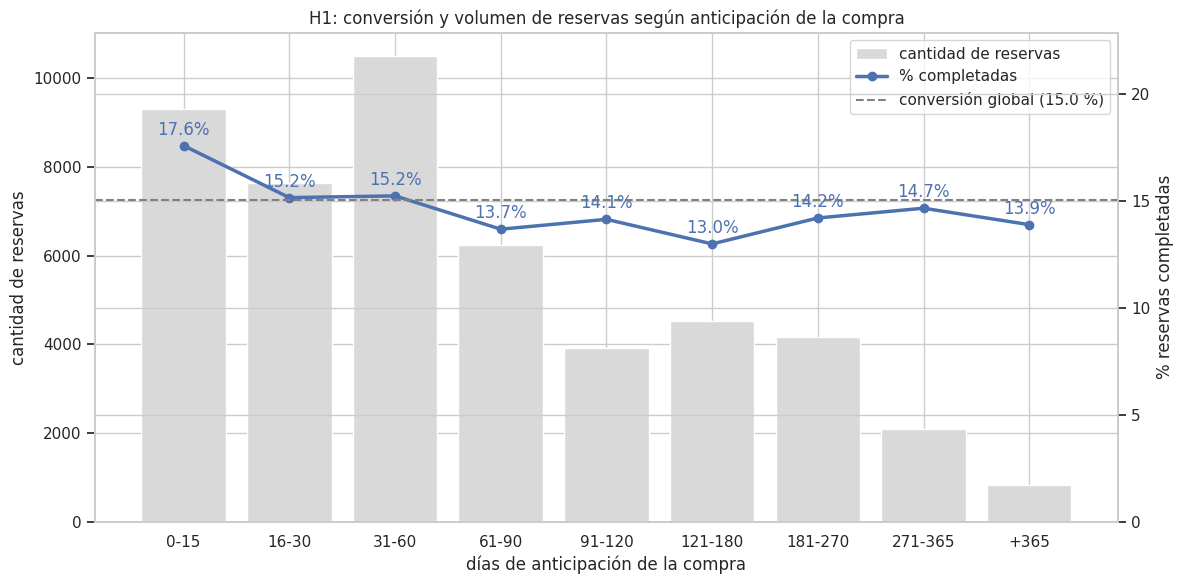

In [374]:
conversion_global = df['booking_complete'].mean() * 100

# Tramos de anticipación más finos al principio, donde se concentran las reservas
grupos = [-1, 15, 30, 60, 90, 120, 180, 270, 365, df['purchase_lead'].max()]
etiquetas = ['0-15', '16-30', '31-60', '61-90', '91-120', '121-180', '181-270', '271-365', '+365']
df['lead_tramo'] = pd.cut(df['purchase_lead'], bins=grupos, labels=etiquetas)
por_tramo = df.groupby('lead_tramo', observed=True)['booking_complete'].agg(reservas='size', conversion='mean')
por_tramo['conversion'] *= 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: volumen de reservas (barras)
ax1.bar(por_tramo.index, por_tramo['reservas'], color='#d9d9d9', label='cantidad de reservas')
ax1.set_xlabel('días de anticipación de la compra')
ax1.set_ylabel('cantidad de reservas')

# Eje derecho: conversión (línea)
ax2 = ax1.twinx()
ax2.plot(por_tramo.index, por_tramo['conversion'], marker='o', color='#4c72b0', linewidth=2.5, label='% completadas')
ax2.axhline(conversion_global, color='gray', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
for x, y in zip(por_tramo.index, por_tramo['conversion']):
    ax2.annotate(f'{y:.1f}%', (x, y), xytext=(0, 8), textcoords='offset points', ha='center', color='#4c72b0')
ax2.set_ylabel('% reservas completadas')
ax2.set_ylim(0, por_tramo['conversion'].max() * 1.3)

# Una sola leyenda para los dos ejes
lineas = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
textos = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lineas, textos, loc='upper right')
plt.title('H1: conversión y volumen de reservas según anticipación de la compra')
plt.tight_layout()
plt.show()

#### H2 — Conversión según extras (barras)
Izquierda: conversión según la **cantidad** de extras. Derecha: conversión de quienes pidieron o no
**cada extra** por separado, para ver cuál está más asociado a completar la reserva.

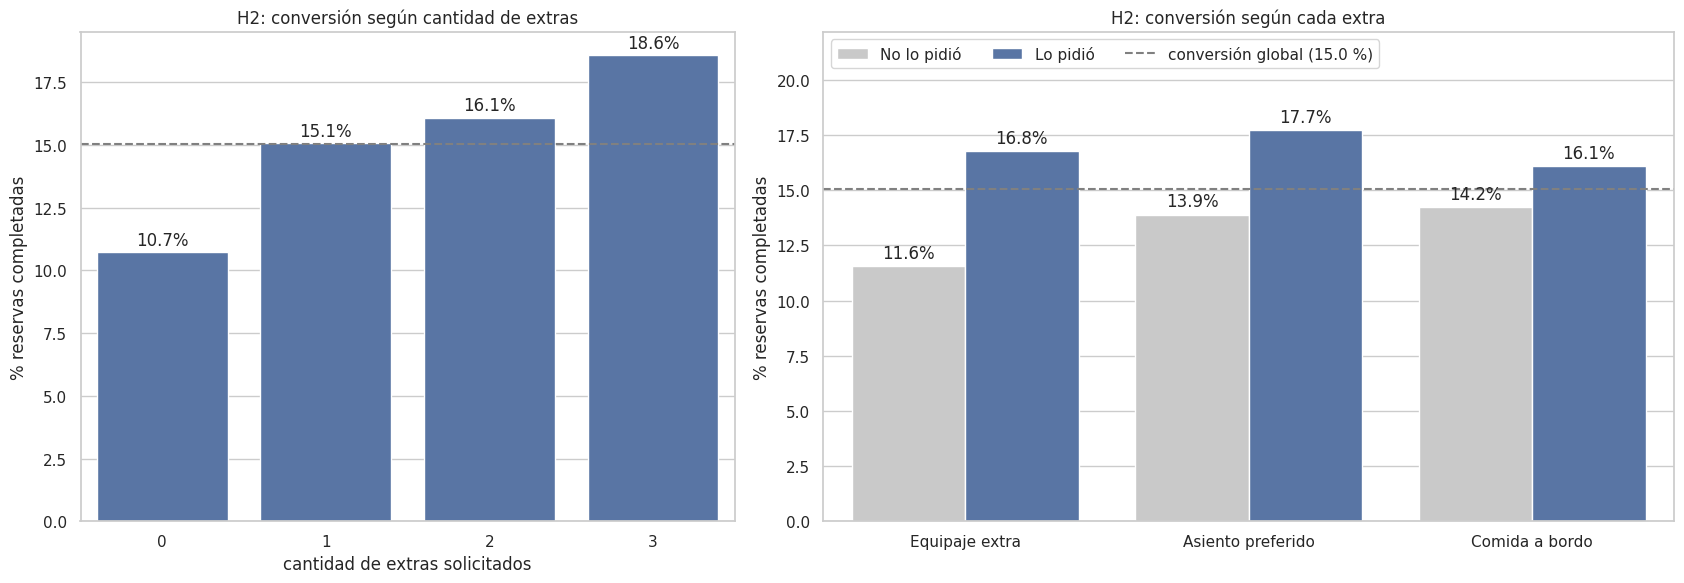

In [375]:
extras = {'wants_extra_baggage': 'Equipaje extra', 'wants_preferred_seat': 'Asiento preferido',
          'wants_in_flight_meals': 'Comida a bordo'}

# Conversión de quienes pidieron / no pidieron cada extra
filas = []
for col, nombre in extras.items():
    for valor, texto in [(0, 'No lo pidió'), (1, 'Lo pidió')]:
        filas.append({'extra': nombre, 'solicitado': texto,
                      'conversion': df.loc[df[col] == valor, 'booking_complete'].mean() * 100})
conv_por_extra = pd.DataFrame(filas)
conv_por_cantidad = df.groupby('total_extras')['booking_complete'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1.3]})

sns.barplot(x=conv_por_cantidad.index, y=conv_por_cantidad.values, color='#4c72b0', ax=axes[0])
for i, v in enumerate(conv_por_cantidad.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center')
axes[0].axhline(conversion_global, color='gray', linestyle='--')
axes[0].set_title('H2: conversión según cantidad de extras')
axes[0].set_xlabel('cantidad de extras solicitados')
axes[0].set_ylabel('% reservas completadas')

sns.barplot(data=conv_por_extra, x='extra', y='conversion', hue='solicitado',
            palette=['#c9c9c9', '#4c72b0'], ax=axes[1])
for barras in axes[1].containers:
    axes[1].bar_label(barras, fmt='%.1f%%', padding=3)
axes[1].axhline(conversion_global, color='gray', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
axes[1].set_title('H2: conversión según cada extra')
axes[1].set_xlabel('')
axes[1].set_ylabel('% reservas completadas')
axes[1].set_ylim(0, conv_por_extra['conversion'].max() * 1.25)
axes[1].legend(title='', loc='upper left', ncol=3)

plt.tight_layout()
plt.show()

#### H3 — Resultado de las reservas por país (barras apiladas al 100 %)
Cada barra es un país (los 10 con más reservas) y suma 100 %: la parte azul son las completadas.
A la derecha, la cantidad de reservas del país, para no confundir peso con conversión.

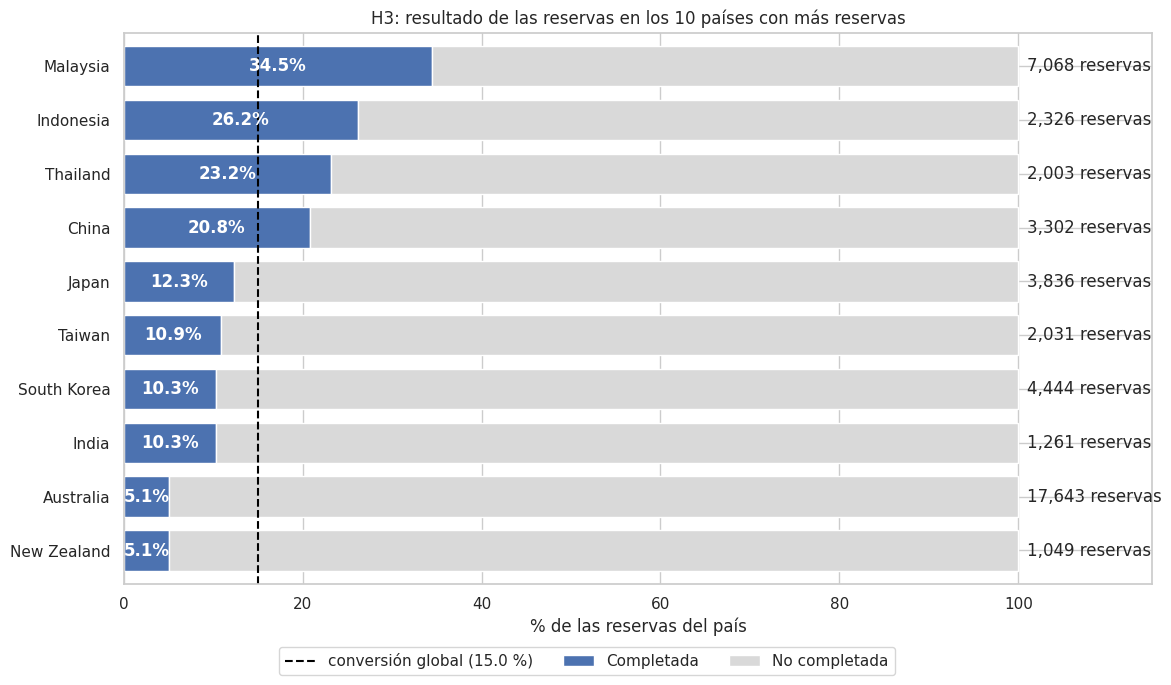

In [376]:
top10 = df['booking_origin'].value_counts().head(10).index

# % de completadas y no completadas dentro de cada país
resultado = (pd.crosstab(df.loc[df['booking_origin'].isin(top10), 'booking_origin'],
                         df['booking_complete'], normalize='index') * 100)
resultado.columns = ['No completada', 'Completada']
resultado = resultado[['Completada', 'No completada']].sort_values('Completada')
reservas_pais = df['booking_origin'].value_counts()

ax = resultado.plot(kind='barh', stacked=True, color=['#4c72b0', '#d9d9d9'], figsize=(12, 7), width=0.75)
for i, pais in enumerate(resultado.index):
    ax.text(resultado.loc[pais, 'Completada'] / 2, i, f"{resultado.loc[pais, 'Completada']:.1f}%",
            va='center', ha='center', color='white', fontweight='bold')
    ax.text(101, i, f'{reservas_pais[pais]:,} reservas', va='center')
ax.axvline(conversion_global, color='black', linestyle='--', label=f'conversión global ({conversion_global:.1f} %)')
ax.set_xlim(0, 115)
ax.set_title('H3: resultado de las reservas en los 10 países con más reservas')
ax.set_xlabel('% de las reservas del país')
ax.set_ylabel('')
ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.1), ncol=3)
plt.tight_layout()
plt.show()

#### Interpretación
- **H1 — se cumple, pero el efecto es chico.** La conversión cae de **17,5 %** (compras con 0-15 días de
  anticipación) a ~**13-14 %** a partir de los 60 días, y después se estabiliza: no sigue bajando.
  Además, el 55 % de las reservas se hacen con menos de 60 días de anticipación.
- **H2 — se cumple.** La conversión sube de forma constante con cada extra: **10,7 % → 15 % → 16 % → 18,5 %**.
  El extra más asociado es el **equipaje** (16,7 % vs 11,5 %, +5,2 puntos), seguido del asiento preferido (+3,9).
  La comida a bordo es la que menos diferencia marca (+1,8).
- **H3 — se cumple con claridad.** Malasia convierte **34,5 %** y Australia **5 %**. Australia concentra
  ≈17.800 reservas (36 % del total) pero solo 1 de cada 20 se completa: es el mercado con más volumen
  y peor conversión.

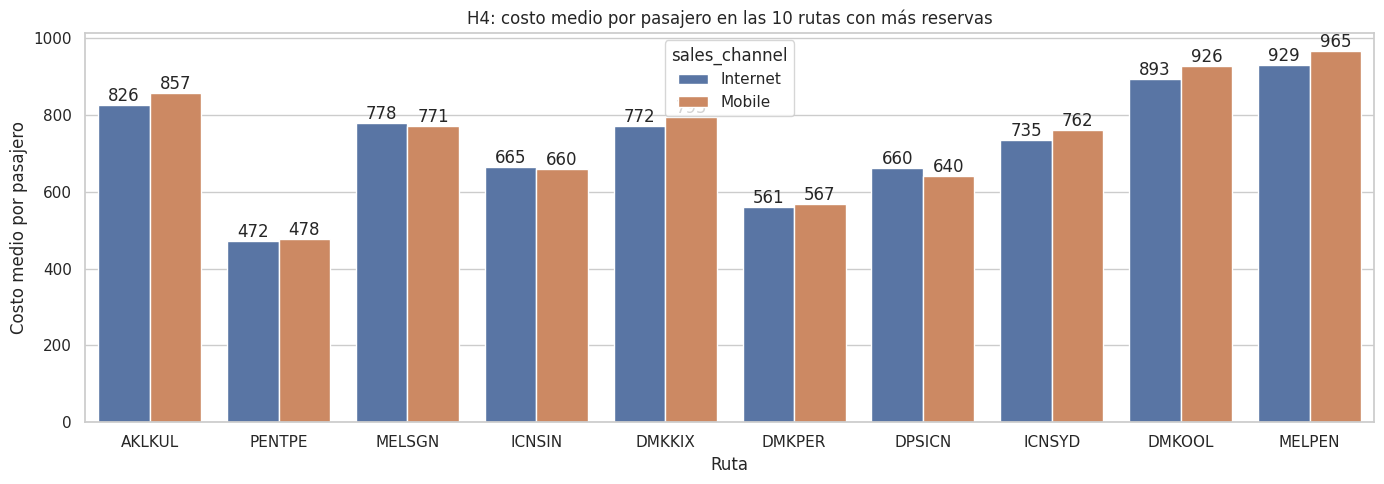

In [377]:
# H4: ante la misma ruta, ¿es más barato Mobile que Internet? (10 rutas con más reservas que tienen ambos canales)
canales_por_ruta = df.groupby('route')['sales_channel'].nunique()
rutas_con_ambos = canales_por_ruta[canales_por_ruta == 2].index

top10_rutas = df[df['route'].isin(rutas_con_ambos)]['route'].value_counts().head(10).index
top10 = df[df['route'].isin(top10_rutas)]

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=top10, x='route', y='cost_per_passenger', hue='sales_channel',
                 order=top10_rutas, errorbar=None)
ax.set_title('H4: costo medio por pasajero en las 10 rutas con más reservas')
ax.set_xlabel('Ruta')
ax.set_ylabel('Costo medio por pasajero')
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.0f')
plt.tight_layout()
plt.show()